In [1]:
using Plots, Printf

In [2]:
# midpoint, in vector N, out vector N-1
function stagav(f)
    N = length(f)
    f_mid = zeros(N-1)
    for i in 1:N-1
        f_mid[i] = 0.5*(f[i]+f[i+1])
    end
    return f_mid
end

stagav (generic function with 1 method)

In [3]:
function DuDx(u, d, F)
    u_x = zeros(N)
    u_x[1] = idx*(u[2]-u[1]) # 1st point
    for i in 2:N-1
        u_x[i] = 0.5*idx*(u[i+1]-u[i-1]) #2nd order centred
    end
    u_x[N] = F/(E*( (1-d[N])^2 + k)) # last point, BC
    return u_x
end

DuDx (generic function with 1 method)

In [25]:
N = 512 + 1 # number of points

u = zeros(N) # displacement ID
d = zeros(N) # phase field ID

E = 2*1e5 # Young's modulus
gc = 1e2 # critical energy
l = 0.01 # phase field reg. length; affects F_break?
k = 1e-6 # numerical; small; for stability (to avoid 1/0)
L = 1 # rod length
F = 5*1e5 # external force

# numerilca grid
x = range(0,L,N+1)
dx = x[2] - x[1]
println(3*dx) # h < l/3 to l/5 for resolution of crack ?
idx = 1/dx

0.005847953216374269


513.0

In [26]:
function loop(u, d, F)
    
    u_x = DuDx(u,d,F) # derivarive of displacement
    H = 0.5*E*u_x.^2 # calculate history

    # rhs for phase field:
    f = 2*l*H
    # matrix for lhs for phase field
    M = zeros(N,N)
    M[1,1] = gc/l + 2*l*gc*idx^2 + 2*H[1]
    M[1,2] = -2*l*gc*idx^2
    for i in 2:N-1
        M[i,i-1] = -l*gc*idx^2
        M[i,i] = gc/l + 2*l*gc*idx^2 + 2*H[i]
        M[i,i+1] = -l*gc*idx^2
    end
    M[N,N-1] = -2*l*gc*idx^2
    M[N,N] = gc/l + 2*l*gc*idx^ + 2*H[N]

    # solve for phase field d; the minus sign on the right not sure
    d = M \ f 

    g = (1.0 .- d).^2 .+ k # degradation function
    g_mid = stagav(g)

    b = zeros(N) # rhs for u
    b[N] = 2*F*dx/(E*g[N]) # boundary condition for u_x

    A = zeros(N,N) # matrix for lhs for u
    A[1,1] = 1.0 # BC for u(0) = 0

    for i in 2:N-1
        #g has length N, g_mid length N-1
        A[i,i-1] = g_mid[i-1] # that is g_{i-1/2}
        A[i,i] = -g_mid[i] - g_mid[i-1] # -g{i+1/2} - g_{i-1/2}
        A[i,i+1] = g_mid[i] # g_{i+1/2}
    end
    g_mid_N = g_mid[end] # copy g_{N-1/2} to g_{N+1/2}, which is missing
    A[N,N] = 1 + g_mid[end]/g_mid_N
    A[N,N-1] = -1 - g_mid[end]/g_mid_N

    u_new = A \ b
    d_new = copy(d)

    return u_new, d_new
end

loop (generic function with 1 method)

In [27]:
for i in 1:100
    u,d = loop(u,d,F)
end

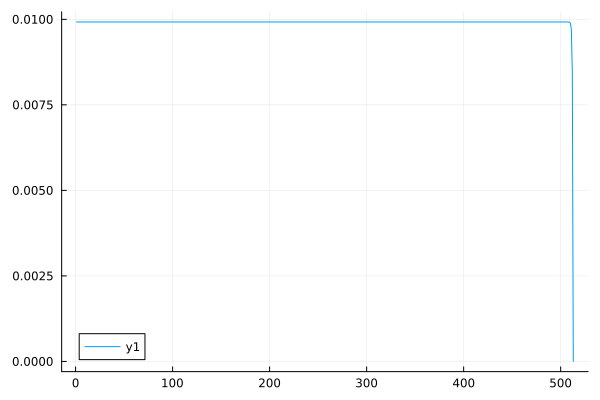

In [28]:
plot(d)

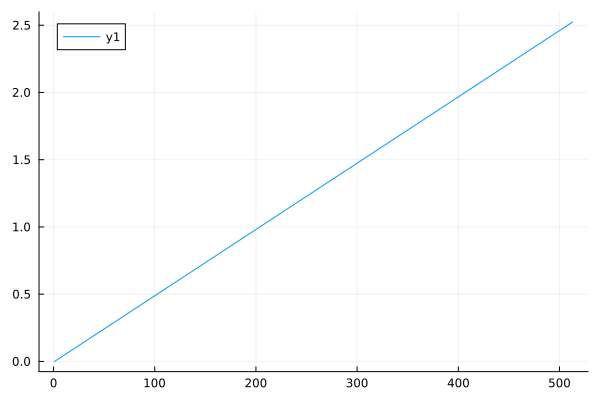

In [29]:
plot(u)

In [ ]:
u_x = DuDx(u,d,F)

In [ ]:
H = 0.5*E*u_x.^2

In [ ]:
# rhs for phase field:
f = 2*l*H
# matrix for lhs for phase field
M = zeros(N,N)
M[1,1] = gc/l + 2*l*gc*idx^2 + 2*H[1]
M[1,2] = -2*l*gc*idx^2
for i in 2:N-1
    M[i,i-1] = -l*gc*idx^2
    M[i,i] = gc/l + 2*l*gc*idx^2 + 2*H[i]
    M[i,i+1] = -l*gc*idx^2
end
M[N,N-1] = -2*l*gc*idx^2
M[N,N] = gc/l + 2*l*gc*idx^ + 2*H[N]


In [ ]:
d = M \ f

In [ ]:
plot(d)


In [ ]:
g = (1.0 .- d).^2 .+ k # degradation function
g_mid = stagav(g)
plot(g)
plot!(g_mid)

In [ ]:
b = zeros(N) # rhs for u
b[N] = 2*F*dx/(E*g[N]) # boundary condition for u_x

A = zeros(N,N) # matrix for lhs for u
A[1,1] = 1.0 # BC for u(0) = 0

for i in 2:N-1
    #g has length N, g_mid length N-1
    A[i,i-1] = g_mid[i-1] # that is g_{i-1/2}
    A[i,i] = -g_mid[i] - g_mid[i-1] # -g{i+1/2} - g_{i-1/2}
    A[i,i+1] = g_mid[i] # g_{i+1/2}
end
g_mid_N = g_mid[end] # copy g_{N-1/2} to g_{N+1/2}, which is missing
A[N,N] = 1 + g_mid[end]/g_mid_N
A[N,N-1] = -1 - g_mid[end]/g_mid_N

u = A \ b

In [ ]:
plot(u)

In [ ]:
function loop(u, d, F)
    
    u_x = DuDx(u,d,F) # derivarive of displacement
    H = 0.5*E*u_x.^2 # calculate history

    # rhs for phase field:
    f = 2*l*H
    # matrix for lhs for phase field
    M = zeros(N,N)
    M[1,1] = gc/l + 2*l*gc*idx^2 + 2*H[1]
    M[1,2] = -2*l*gc*idx^2
    for i in 2:N-1
        M[i,i-1] = -l*gc*idx^2
        M[i,i] = gc/l + 2*l*gc*idx^2 + 2*H[i]
        M[i,i+1] = -l*gc*idx^2
    end
    M[N,N-1] = -2*l*gc*idx^2
    M[N,N] = gc/l + 2*l*gc*idx^ + 2*H[N]

    # solve for phase field d; the minus sign on the right not sure
    d = M \ -f 

    g = (1.0 .- d).^2 .+ k # degradation function
    g_mid = stagav(g)

    b = zeros(N) # rhs for u
    b[N] = 2*F*dx/(E*g[N]) # boundary condition for u_x

    A = zeros(N,N) # matrix for lhs for u
    A[1,1] = 1.0 # BC for u(0) = 0

    for i in 2:N-1
        #g has length N, g_mid length N-1
        A[i,i-1] = g_mid[i-1] # that is g_{i-1/2}
        A[i,i] = -g_mid[i] - g_mid[i-1] # -g{i+1/2} - g_{i-1/2}
        A[i,i+1] = g_mid[i] # g_{i+1/2}
    end
    g_mid_N = g_mid[end] # copy g_{N-1/2} to g_{N+1/2}, which is missing
    A[N,N] = 1 + g_mid[end]/g_mid_N
    A[N,N-1] = -1 - g_mid[end]/g_mid_N

    u_new = A \ b
    d_new = copy(d)

    return u_new, d_new
end

In [ ]:
u2, d2 = loop(u, d, F)

In [ ]:
plot(u)
plot!(u2)

In [ ]:
plot(d)
plot!(d2)

In [ ]:
u3, d3 = loop(u2, d2, F)

In [ ]:
u3.-u2

In [ ]:
plot(d3)

In [ ]:
d3.-d2

In [ ]:
for i in 1:100
    u,d = loop(u,d,F)
end

In [ ]:
plot(u)

In [ ]:
plot(d)